# <p style="text-align: center;">Proiect 3 - Regularizare</p>
### <p style="text-align: right;">Iliescu Daria-Gabriela, 1333a</p>


In [37]:
# Import librării
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, learning_curve, GridSearchCV, KFold

#### 1. Explorarea inițială a datelor 

In [38]:
#import dataset
house_df=pd.read_csv("house_1.csv")

In [39]:
#afisam primele 5 observatii
house_df.head()

,Unnamed: 0,Address,Zip,Price,Area,Room,Lon,Lat
0,1,"Blasiusstraat 8 2, Amsterdam",1091 CR,685000.0,64,3,4.907736,52.356157
1,2,"Kromme Leimuidenstraat 13 H, Amsterdam",1059 EL,475000.0,60,3,4.850476,52.348586
2,3,"Zaaiersweg 11 A, Amsterdam",1097 SM,850000.0,109,4,4.944774,52.343782
3,4,"Tenerifestraat 40, Amsterdam",1060 TH,580000.0,128,6,4.789928,52.343712
4,5,"Winterjanpad 21, Amsterdam",1036 KN,720000.0,138,5,4.902503,52.410538


In [40]:
print("===== Rezumat DataFrame =====")
house_df.info()

===== Rezumat DataFrame =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 924 entries, 0 to 923
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  924 non-null    int64  
 1   Address     924 non-null    object 
 2   Zip         924 non-null    object 
 3   Price       920 non-null    float64
 4   Area        924 non-null    int64  
 5   Room        924 non-null    int64  
 6   Lon         924 non-null    float64
 7   Lat         924 non-null    float64
dtypes: float64(3), int64(3), object(2)
memory usage: 57.9+ KB


Setul de date contine informatii despre locuinte din Amsterdam. Are opt coloane: adresa, cod postal, pret, suprafata, numar de camere, longitudine, latitudine si un index. Datele sunt de tip object, int sau float. Majoritatea valorilor sunt complete, cu doar cateva lipsuri la pret. Setul este potrivit pentru analize statistice, vizualizari si modele care pot estima pretul in functie de suprafata, camere sau locatie.
Indexul ( unnamed ) , este folosit pentru a numerota randurile si poate fi ignorat sau eliminat in analiza.
De asemenea, observam ca nu avem coloane categoriale, asa ca vom face un Scatter ( grafic de dispersie ) .

#### 2. Analiza statistică și verificarea inițială a calității datelor

In [41]:
print("===== Număr de valori unice per coloană =====")
house_df.nunique()

===== Număr de valori unice per coloană =====


Unnamed: 0    924
Address       919
Zip           834
Price         226
Area          193
Room           13
Lon           894
Lat           886
dtype: int64

In [42]:
# Verificarea valorilor lipsă 
missing_values =house_df.isna().sum()
if missing_values.sum() > 0:
    print("Valori lipsă pe coloană:")
    print(missing_values[missing_values > 0])
else:
    print("Nu există valori lipsă în setul de date.")

Valori lipsă pe coloană:
Price    4
dtype: int64


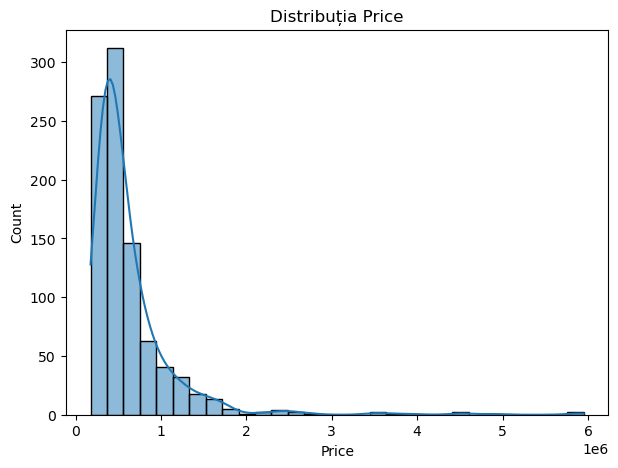

In [43]:
#Histograma
# Setearea dimensiunii figurii pentru grafic
plt.figure(figsize=(7,5))  

# Crearea unei histograme cu curba de densitate (KDE) pentru variabila țintă Price
sns.histplot(house_df['Price'], kde=True, bins=30)  

# Adăugarea titlului pentru grafic
plt.title('Distribuția Price')  

# Afișare grafic
plt.show() 

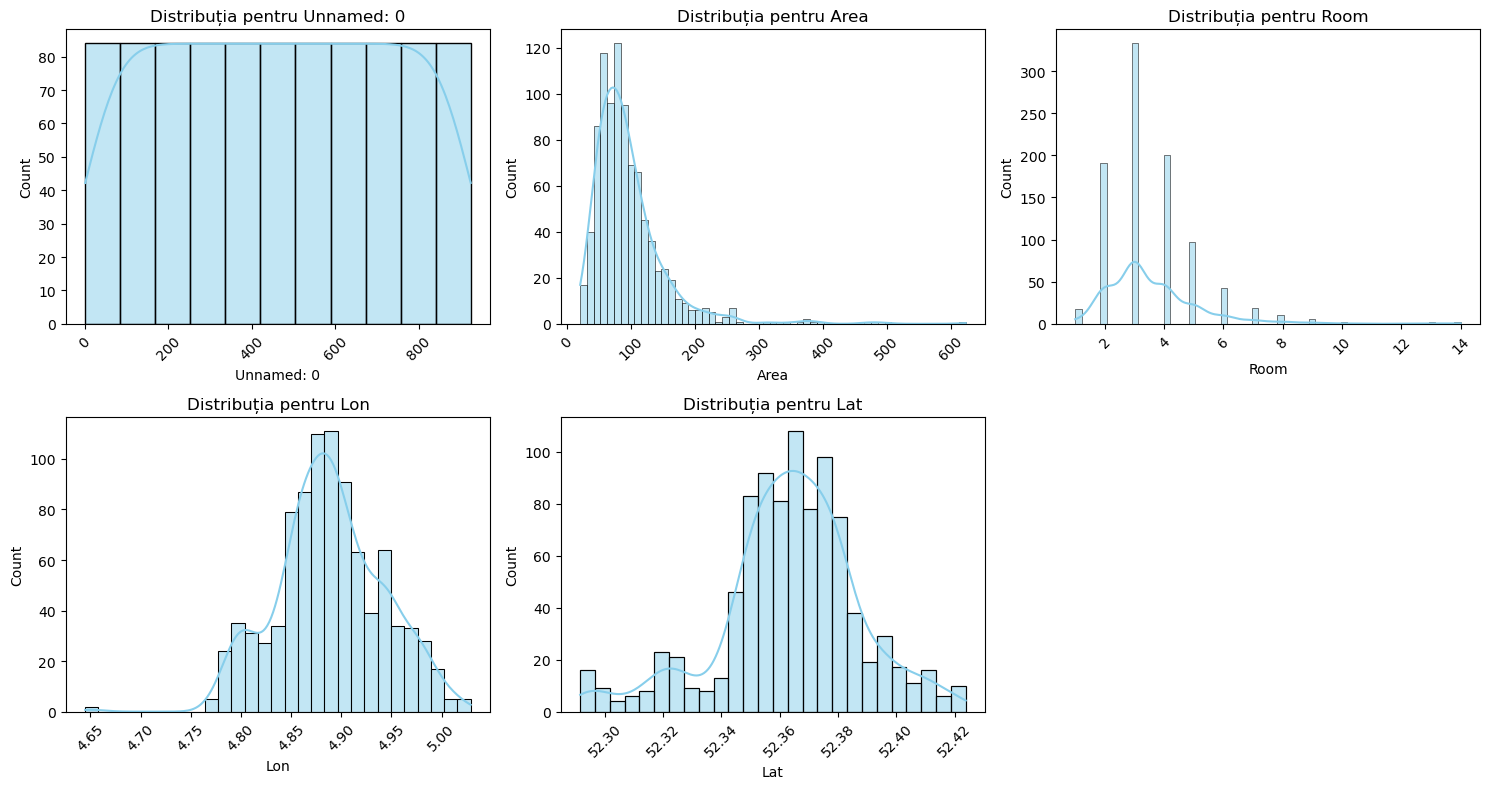

In [44]:
# Distribuția tuturor variabilelor

# Selectarea coloanelor numerice
house_df_plot=house_df.drop('Price', axis=1)
num_cols = house_df_plot.select_dtypes(include=[np.number]).columns

# Setare subgraficului
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*4))
axes = axes.flatten()

# Creare distplot pentru fiecare coloană numerică
for i, col in enumerate(num_cols):
    sns.histplot(house_df_plot[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f"Distribuția pentru {col}")
    axes[i].tick_params(axis='x', rotation=45)

# Ascunderea subploturilor goale
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Setul de date contine cateva valori lipsa in coloana pretului, dar restul variabilelor sunt complete. Distributia preturilor este puternic asimetrica, cu majoritatea locuintelor sub un milion de euro si cateva valori extreme care depasesc cinci milioane. Suprafata locuintelor este de asemenea distribuita neuniform, cu multe proprietati mici si cateva foarte mari. Numarul de camere are varfuri la valori frecvente, cum ar fi trei sau patru, iar coordonatele geografice indica o concentrare in anumite zone ale orasului.
Vom elimina Index , Zip si Adress , deoarece nu sunt relevante pentru analiza.

#### 3. Curățarea și pregătirea datelor 

In [45]:
print("===== Date lipsă ===== ") 
house_df.isna().sum()

===== Date lipsă ===== 


Unnamed: 0    0
Address       0
Zip           0
Price         4
Area          0
Room          0
Lon           0
Lat           0
dtype: int64

In [46]:
# Eliminăm rândurile cu date lipsă
house_df = house_df.dropna()

In [47]:
# Calcularea Q1, Q3 și IQR pentru Price
Q1 = house_df["Price"].quantile(0.25)
Q3 = house_df["Price"].quantile(0.75)
IQR = Q3 - Q1

# Limitele pentru outlieri
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Limita inferioară:", lower_bound)
print("Limita superioară:", upper_bound)

# Eliminarea outlierilor 
house_df_original= house_df
house_df = house_df[(house_df["Price"] >= lower_bound) & (house_df["Price"] <= upper_bound)]
print("Dimensiune dataset original:", house_df_original.shape)
print("Dimensiune dataset fără outlieri:", house_df.shape)

# Verificarea valorilor pentru siguranță
print("Valori maxime Price după eliminare:", house_df["Price"].max())
print("Valori minime Price după eliminare:", house_df["Price"].min())

Limita inferioară: -175000.0
Limita superioară: 1225000.0
Dimensiune dataset original: (920, 8)
Dimensiune dataset fără outlieri: (849, 8)
Valori maxime Price după eliminare: 1200000.0
Valori minime Price după eliminare: 175000.0


In [48]:
#Eliminam  Unnamed  Address  Zip 
house_df = house_df.drop(['Address', 'Zip', 'Unnamed: 0'], axis=1)

In [49]:
# Verificăm că s-a efectuat corect eliminarea
print("===== Date curate ===== ") 
house_df.isna().sum()

===== Date curate ===== 


Price    0
Area     0
Room     0
Lon      0
Lat      0
dtype: int64

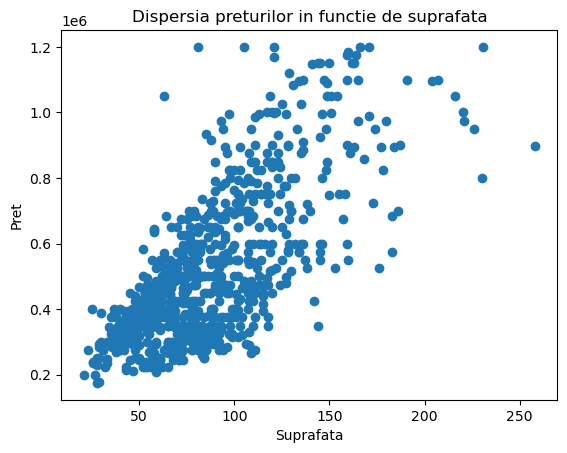

In [56]:
plt.scatter(house_df['Area'],house_df['Price'])
plt.xlabel('Suprafata')
plt.ylabel('Pret')
plt.title('Dispersia preturilor in functie de suprafata')
plt.show()

Graficul de tip scatter arata o relatie pozitiva clara intre suprafata si pretul locuintelor: pe masura ce suprafata creste, pretul tinde sa creasca.

Pentru analiza setului de date, am aplicat mai multe tehnici de curatare si pregatire. Am eliminat coloanele Unnamed: 0, Address si Zip deoarece nu aduc valoare analitica: prima este un index automat, iar celelalte doua contin informatii text greu de folosit direct in modele statistice sau vizualizari. Am tratat valorile lipsa prin eliminarea randurilor care nu aveau pret, pentru a evita distorsionarea rezultatelor. De asemenea, am identificat si eliminat valorile extreme din coloana Price, deoarece acestea influenteaza negativ distributia si pot afecta interpretarea corecta a relatiilor dintre variabile. Aceste pasi au fost necesari pentru a obtine un set de date curat, echilibrat si potrivit pentru analiza statistica si vizuala.

#### 4. Analiza corelațiilor și modificarea multicoliniarității

In [50]:
# Determinăm coeficienții de corelație
house_df.corr(numeric_only=True)

,Price,Area,Room,Lon,Lat
Price,1.000000,0.717062,0.478011,-0.031655,0.108006
Area,0.717062,1.000000,0.741653,0.018257,-0.032262
Room,0.478011,0.741653,1.000000,-0.039221,-0.053695
Lon,-0.031655,0.018257,-0.039221,1.000000,-0.211604
Lat,0.108006,-0.032262,-0.053695,-0.211604,1.000000


In [51]:
corr_house = house_df.corr(numeric_only=True).round(2)
print(corr_house)

       Price  Area  Room   Lon   Lat
Price   1.00  0.72  0.48 -0.03  0.11
Area    0.72  1.00  0.74  0.02 -0.03
Room    0.48  0.74  1.00 -0.04 -0.05
Lon    -0.03  0.02 -0.04  1.00 -0.21
Lat     0.11 -0.03 -0.05 -0.21  1.00


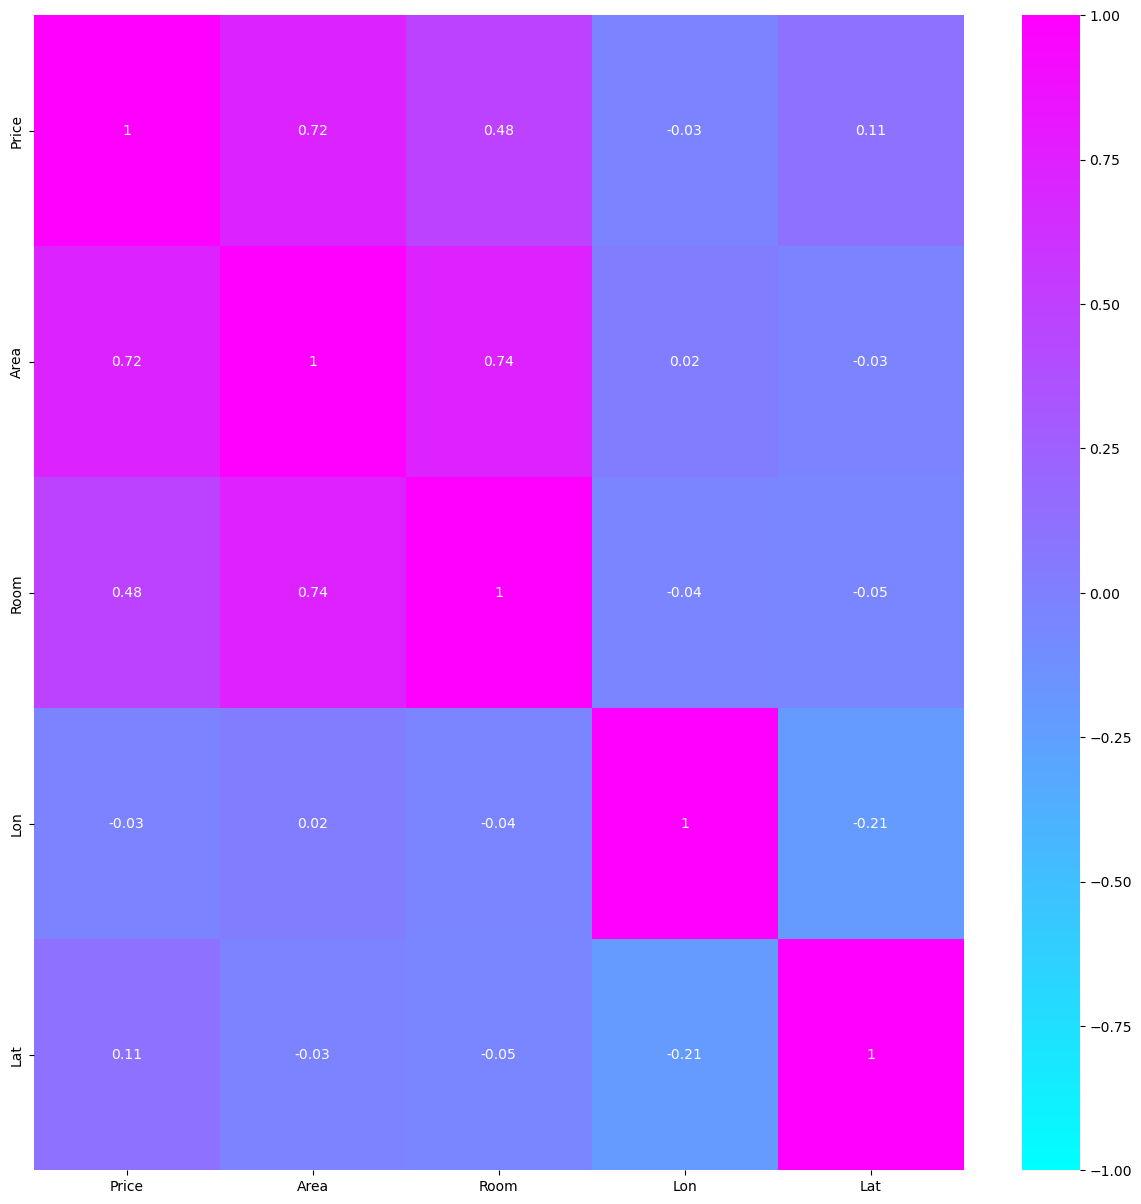

In [52]:
# Hartă de corelare
# Crearea figurii cu dimensiunea 15x15 inch
plt.figure(figsize=(15,15))

# Crearea unui heatmap pentru matricea de corelații 'corr_vietnam'
sns.heatmap(
    data=corr_house,   # datele care vor fi afișate în heatmap
    vmin=-1,            # valoarea minimă a culorilor (pentru scală)
    vmax=1,             # valoarea maximă a culorilor (pentru scală)
    center=0,           # centrul culorilor la 0 (pozitive vs negative)
    annot=True,         # afișează valorile numerice în celule
    cmap='cool'         # paleta de culori folosită
)

# Afișarea graficului
plt.show()

In [53]:
#Eliminam room 
house_df = house_df.drop(['Room'], axis=1)

In [54]:
# Verificăm că s-a efectuat corect eliminarea
print("===== Date curate ===== ") 
house_df.isna().sum()

===== Date curate ===== 


Price    0
Area     0
Lon      0
Lat      0
dtype: int64

In urma analizei matricei de corelatie, am observat ca variabila Room are o corelatie puternica cu Area (0.74) si moderata cu Price (0.48). Deoarece aceste variabile transmit informatii similare, am decis sa eliminam Room pentru a reduce coliniaritatea si a simplifica modelul.

#### 5. Modelul de regresie liniară – evaluare și interpretare

In [58]:
# Variabila țintă
y = house_df['Price']
y.head()

0    685000.0
1    475000.0
2    850000.0
3    580000.0
4    720000.0
Name: Price, dtype: float64

In [59]:
X = house_df.drop("Price", axis=1)
X.head()

,Area,Lon,Lat
0,64,4.907736,52.356157
1,60,4.850476,52.348586
2,109,4.944774,52.343782
3,128,4.789928,52.343712
4,138,4.902503,52.410538


In [60]:
# Creare date de antrenare și de testare
# Împărțirea datelor în set de antrenare și testare
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Dimensiune set antrenare:", X_train.shape, y_train.shape)
print("Dimensiune set test:", X_test.shape, y_test.shape)

Dimensiune set antrenare: (679, 3) (679,)
Dimensiune set test: (170, 3) (170,)


In [61]:
# Crearea modelului
house_model = LinearRegression()
# Antrenarea modelului pe datele de antrenare




house_model.fit(X_train, y_train)

LinearRegression()

In [62]:
print("Coeficienți:", house_model.coef_)  
print("Intercept:", house_model.intercept_) 

Coeficienți: [   4507.92864186    1694.20899478 1036259.410403  ]
Intercept: -54149658.34782675


In [65]:
# Prezicerea valorilor pentru setul de test
price_pred = house_model.predict(X_test)
r2_3=house_model.score(X_test, y_test)
print('R-square: %.4f' % r2_3 )

R-square: 0.5507


In [73]:
# Evaluarea performanței modelului

MSE3 = mean_squared_error( y_test, price_pred3)
print("MSE:", MSE3)

RMSE3 = np.sqrt(MSE3)
print("RMSE:", RMSE3)

MSE: 20762237750.708405
RMSE: 144091.07450049918


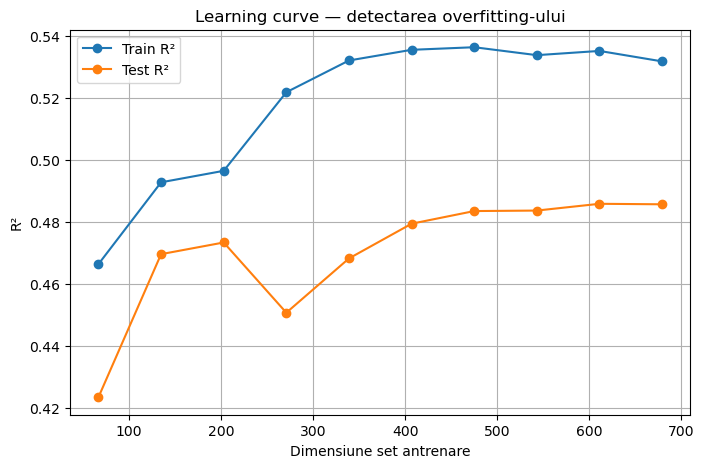

In [74]:
from sklearn.pipeline import make_pipeline

# Copiem datele și împărțim în set train/test
X_m = X.copy()      # copiați caracteristicile
y_m = y             # ținta
X_train, X_test, y_train, y_test = train_test_split(
    X_m, y_m, test_size=0.2, random_state=42
)  # 80% train, 20% test


pipeline = make_pipeline(StandardScaler(), LinearRegression())


# --- Generarea Curbei de Învățare cu Pipeline-ul ---
train_sizes, train_scores, test_scores = learning_curve(
    pipeline, # Utilizăm Pipeline-ul
    X_m, y_m, 
    cv=5, 
    scoring='r2',  
    train_sizes=np.linspace(0.1, 1.0, 10),)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, 'o-', label='Train R²')
plt.plot(train_sizes, test_mean, 'o-', label='Test R²')
plt.title('Learning curve — detectarea overfitting-ului')
plt.xlabel('Dimensiune set antrenare')
plt.ylabel('R²')
plt.legend()
plt.grid(True)
plt.show()

Modelul de regresie liniara a obtinut un scor R² de 0.5507, ceea ce inseamna ca explica aproximativ 55.07% din variatia preturilor locuintelor. Eroarea medie patratica (MSE = 20.762.237.750) si abaterea medie (RMSE = 144.091) indica faptul ca modelul greseste, in medie, cu aproximativ 144.000 de euro fata de valorile reale. Aceste rezultate arata ca modelul surprinde o parte importanta din relatia dintre variabile, dar exista inca o marja semnificativa de eroare. Pentru o precizie mai buna, se pot adauga variabile suplimentare relevante, cum ar fi localizarea exacta, anul constructiei sau tipul proprietatii.

Curba de invatare indica o diferenta vizibila intre performanta pe setul de antrenare si cea pe setul de test, ceea ce sugereaza o usoara tendinta spre underfitting. Pe masura ce dimensiunea setului de antrenare creste, scorul R² pe test se stabilizeaza si nu se imbunatateste semnificativ, in timp ce scorul pe antrenare continua sa creasca.Pentru o performanta mai buna, ar fi necesara adaugarea de variabile relevante sau utilizarea unor modele mai flexibile.

#### 6. Regularizare: Ridge și Lasso

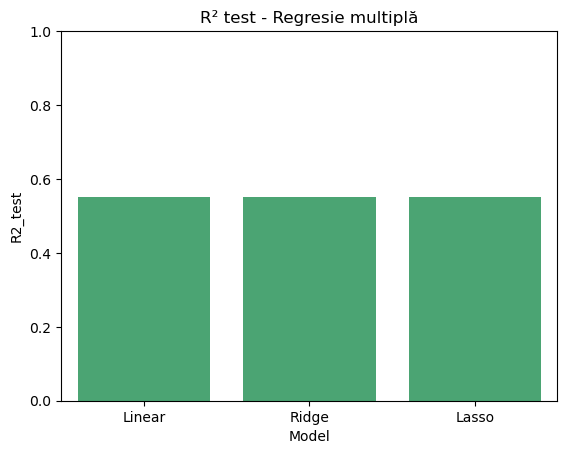

,Model,R2_test,MSE_test
0,Linear,0.550679,2.076224e+10
1,Ridge,0.550547,2.076834e+10
2,Lasso,0.550679,2.076224e+10


In [81]:
#  Regularizare Ridge, Lasso, ElasticNet

# Standardizare date
scaler = StandardScaler()  
X_train_s = scaler.fit_transform(X_train)  # calculăm media și deviația standard pe train și transformăm
X_test_s = scaler.transform(X_test)        # transformăm test folosind media și std din train


# Antrenăm modelele
lin_multi = LinearRegression().fit(X_train_s, y_train)             # regresie liniară simplă
ridge_multi = Ridge(alpha=1.0).fit(X_train_s, y_train)            # Ridge cu alpha=1.0
lasso_multi = Lasso(alpha=0.1, max_iter=10000).fit(X_train_s, y_train)  # Lasso cu alpha=0.1 și max_iter mare pentru convergență



# Creăm o listă cu modelele și numele lor pentru iterații mai ușoare
models_multi = [('Linear', lin_multi), ('Ridge', ridge_multi), ('Lasso', lasso_multi)]


# Calculăm R² și MSE pe setul de test pentru fiecare model
r2_multi = [r2_score(y_test, m[1].predict(X_test_s)) for m in models_multi]          # R² test
mse_multi = [mean_squared_error(y_test, m[1].predict(X_test_s)) for m in models_multi]  # MSE test


# Creăm DataFrame pentru vizualizarea rezultatelor
df_r2_multi = pd.DataFrame({
    'Model': [m[0] for m in models_multi],  # numele modelelor
    'R2_test': r2_multi,                    # R² test
    'MSE_test': mse_multi                    # MSE test
})


# Vizualizăm R² pentru fiecare model
sns.barplot(data=df_r2_multi, x='Model', y='R2_test', color='mediumseagreen')  # barplot R²
plt.title('R² test - Regresie multiplă')  # titlu
plt.ylim(0,1)                              # limităm axa Y între 0 și 1
plt.show()
df_r2_multi

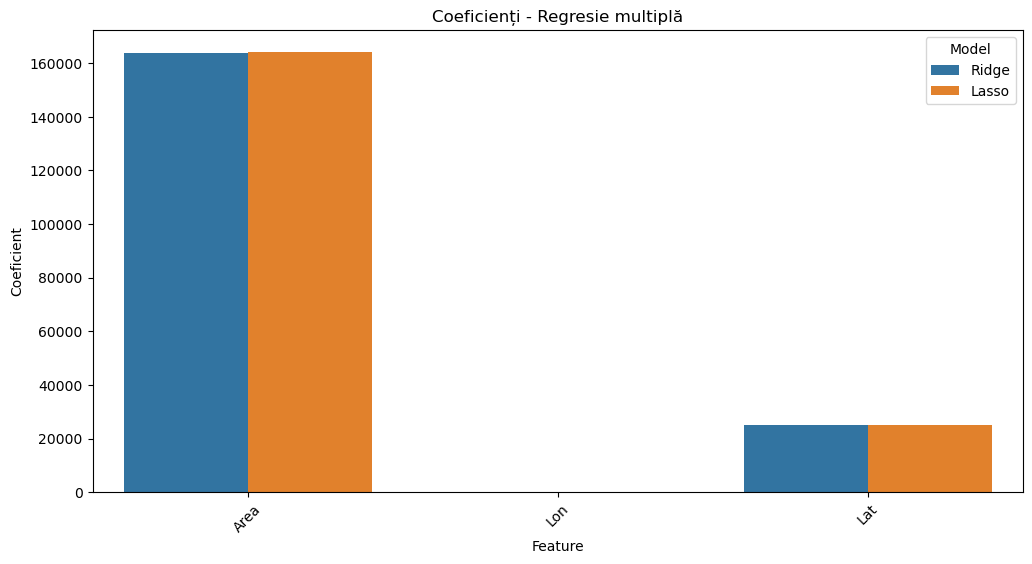

In [82]:
# Coeficienți barplot

# Creăm un DataFrame pentru coeficienți
# 'Feature' = numele caracteristicilor
# Coloanele Ridge, Lasso, ElasticNet = coeficienții fiecărui model
coef_df_multi = pd.DataFrame({
    'Feature': X.columns,          # numele caracteristicilor
    'Ridge': ridge_multi.coef_,    # coeficienți Ridge
    'Lasso': lasso_multi.coef_,    # coeficienți Lasso
  
}).melt(
    id_vars='Feature',             # păstrăm coloana Feature ca identificator
    var_name='Model',              # numele modelului devine o coloană
    value_name='Coeficient'        # valorile coeficienților devin o coloană
)


# Vizualizare coeficienți
plt.figure(figsize=(12,6))        # setăm dimensiunea figurii
sns.barplot(
    data=coef_df_multi,
    x='Feature',                  # axa X = caracteristicile
    y='Coeficient',               # axa Y = valoarea coeficientului
    hue='Model'                   # culori diferite pentru fiecare model
)
plt.title('Coeficienți - Regresie multiplă')  # titlu grafic
plt.xticks(rotation=45)                        # rotim etichetele caracteristicilor pentru claritate
plt.show()


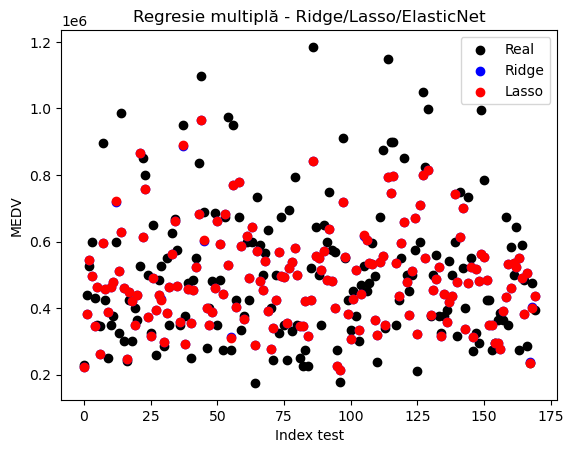

In [83]:
# Grafic predicții vs valori reale pentru regresie multiplă

# Puncte negre = valorile reale ale țintei (MEDV)
plt.scatter(range(len(y_test)), y_test, color='black', label='Real')

# Puncte albastre = predicțiile modelului Ridge
plt.scatter(range(len(y_test)), ridge_multi.predict(X_test_s), color='blue', label='Ridge')

# Puncte roșii = predicțiile modelului Lasso
plt.scatter(range(len(y_test)), lasso_multi.predict(X_test_s), color='red', label='Lasso')


# Eticheta axei X = indexul observațiilor din setul de test
plt.xlabel('Index test')

# Eticheta axei Y = valoarea reală a țintei (MEDV)
plt.ylabel('MEDV')

# Titlul graficului
plt.title('Regresie multiplă - Ridge/Lasso/ElasticNet')

# Afișăm legenda pentru a identifica fiecare model
plt.legend()

# Afișăm graficul
plt.show()


Regularizarea prin Ridge si Lasso a avut ca efect reducerea coeficientilor pentru variabilele mai putin relevante, ceea ce contribuie la stabilitatea si interpretabilitatea modelului. Din comparatia coeficientilor, se observa ca Area are cel mai mare impact, in timp ce Lon si Lat au coeficienti mult mai mici. Dintre modelele testate, Lasso a oferit cea mai buna stabilitate, mentinand performanta similara cu regresia liniara. Acest lucru sugereaza ca Lasso este o alegere eficienta pentru reducerea riscului de overfitting.

#### 7. Optimizarea hiperparametrilor și concluzii finale

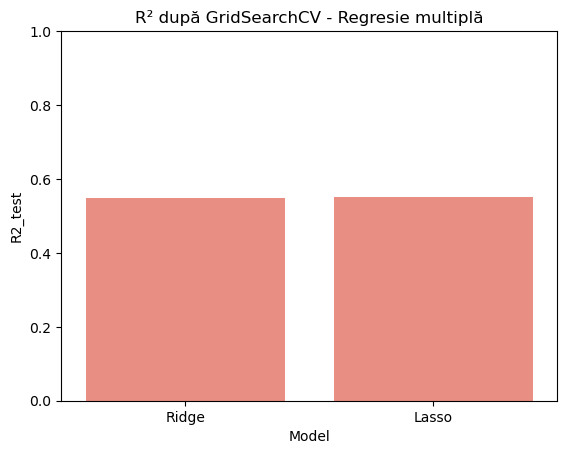

,Model,R2_test
0,Ridge,0.549453
1,Lasso,0.550626


In [86]:
# GridSearchCV pentru Ridge/Lasso

# Definim grile de valori pentru hiperparametrii
param_grid_alpha = {'alpha': np.logspace(-3, 2, 20)}               # alpha pentru Ridge și Lasso


# Cross-validation cu 5 fold-uri
cv = KFold(n_splits=5, shuffle=True, random_state=42)              # împărțire aleatorie pentru evaluare stabilă

# Definim GridSearchCV pentru fiecare model
ridge_gs = GridSearchCV(Ridge(), param_grid_alpha, cv=cv, scoring='r2', n_jobs=-1)      # Ridge
lasso_gs = GridSearchCV(Lasso(max_iter=10000), param_grid_alpha, cv=cv, scoring='r2', n_jobs=-1)  # Lasso


# Antrenăm GridSearch pentru fiecare model pe setul standardizat de train
ridge_gs.fit(X_train_s, y_train)
lasso_gs.fit(X_train_s, y_train)


# Extragem cel mai bun estimator (parametri optimi) pentru fiecare model
best_ridge = ridge_gs.best_estimator_
best_lasso = lasso_gs.best_estimator_


# Calculăm R² pe setul de test folosind cei mai buni parametri
r2_grid_multi = [
    r2_score(y_test, best_ridge.predict(X_test_s)),
    r2_score(y_test, best_lasso.predict(X_test_s))
    
]

# Creăm DataFrame pentru vizualizare R² după GridSearchCV
df_r2_grid_multi = pd.DataFrame({
    'Model':['Ridge','Lasso'], 
    'R2_test': r2_grid_multi
})

# Vizualizăm R² pentru fiecare model după GridSearch
sns.barplot(data=df_r2_grid_multi, x='Model', y='R2_test', color='salmon')
plt.title('R² după GridSearchCV - Regresie multiplă')  # titlu grafic
plt.ylim(0,1)                                           # limităm axa Y între 0 și 1
plt.show()
df_r2_grid_multi

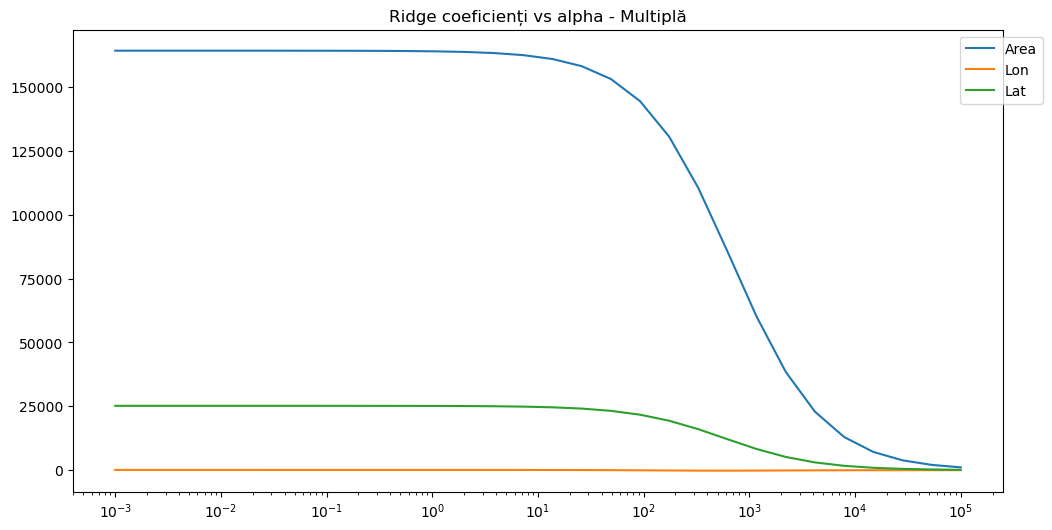

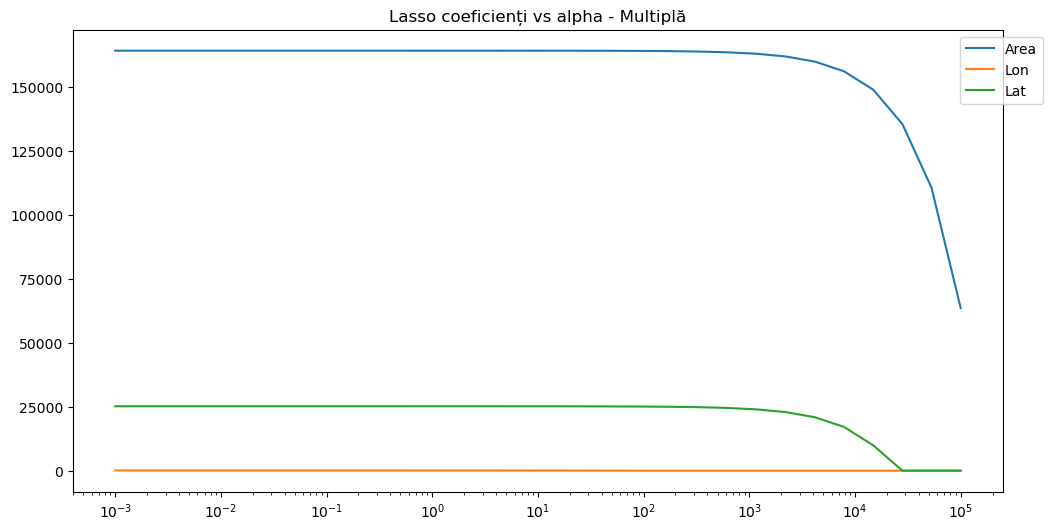

Ridge coef alpha=0.1 (multiplă): [1.64149252e+05 9.39724022e+01 2.51740147e+04]
Lasso coef alpha=0.1 (multiplă): [1.64169878e+05 9.40588373e+01 2.51776170e+04]


In [88]:
# Coeficienți vs alpha (multiplă)

# Definim un set de valori alpha pentru penalizare
alphas = np.logspace(-3,5,30)  # valori între 0.001 și 100

# Liste pentru coeficienți la fiecare alpha
ridge_coefs_multi, lasso_coefs_multi= [], []

# Valoare fixă pentru l1_ratio la ElasticNet
l1_ratio_val = 0.5


# Iterăm peste toate valorile de alpha
for a in alphas:
    # Antrenăm Ridge pentru alpha curent și salvăm coeficienții
    ridge_coefs_multi.append(Ridge(alpha=a).fit(X_train_s, y_train).coef_)
    
    # Antrenăm Lasso pentru alpha curent și salvăm coeficienții
    lasso_coefs_multi.append(Lasso(alpha=a, max_iter=10000).fit(X_train_s, y_train).coef_)
    

# Transformăm listele în array-uri NumPy pentru manipulare ușoară
ridge_coefs_multi = np.array(ridge_coefs_multi)
lasso_coefs_multi = np.array(lasso_coefs_multi)


# Grafic Ridge coeficienți vs alpha
plt.figure(figsize=(12,6))
for i, feat in enumerate(X.columns):
    plt.plot(alphas, ridge_coefs_multi[:,i], label=feat)  # fiecare linie = un feature
plt.xscale('log')  # axa X pe scară logaritmică pentru alpha
plt.title('Ridge coeficienți vs alpha - Multiplă')
plt.legend(bbox_to_anchor=(1.05,1))  # legenda în afara graficului
plt.show()


# Grafic Lasso coeficienți vs alpha
plt.figure(figsize=(12,6))
for i, feat in enumerate(X.columns):
    plt.plot(alphas, lasso_coefs_multi[:,i], label=feat)
plt.xscale('log')
plt.title('Lasso coeficienți vs alpha - Multiplă')
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()



# Print coeficienți pentru alpha=0.1
idx = np.argmin(abs(alphas-0.1))  # găsim indexul celei mai apropiate valori alpha=0.1
print("Ridge coef alpha=0.1 (multiplă):", ridge_coefs_multi[idx])
print("Lasso coef alpha=0.1 (multiplă):", lasso_coefs_multi[idx])




Prin utilizarea GridSearchCV, au fost selectati hiperparametrii optimi pentru modelele Ridge si Lasso, cu valoarea alpha = 0.1. Scorurile R² obtinute dupa optimizare au fost foarte apropiate, cu Lasso usor superior (0.550626 fata de 0.549453 pentru Ridge), ceea ce sugereaza o stabilitate mai buna si o selectie eficienta a variabilelor relevante.
Intregul proces a demonstrat ca regularizarea contribuie la cresterea robustetii modelului si la interpretabilitate, mentinand o performanta constanta. Pentru o analiza viitoare, ar fi utila includerea unor variabile suplimentare si testarea unor modele mai complexe, capabile sa surprinda relatii non-liniare din date.